<div style="text-align: center; color: #D4AF37;">
    
 </h2>
    <h3>Project: Facial Expression Recognition</h3>
</div>


<div style="; color: #D4AF37;">
    <h1>1- Import required libraries</h1>
    
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



<div style="; color: #D4AF37;">
    <h1>1-settings</h1>
    
</div>

In [3]:

DATASET_PATH = r"C:\Users\NO1SC\OneDrive\Desktop\KSIU\Machine Learning\New folder (3)"




<div style="; color: #D4AF37;">
    <h1>2-Load Images From Folders</h1>
    
</div>

In [5]:
import os
import cv2
import numpy as np

DATASET_PATH = r"C:\Users\NO1SC\OneDrive\Desktop\KSIU\Machine Learning\New folder (3)"
IMG_SIZE = (48, 48)

def load_images_from_folder(root_dir, img_size):
    if not os.path.exists(root_dir):
        raise FileNotFoundError(f"المجلد غير موجود في: {root_dir}")
    X, y = [], []
    classes = sorted([c for c in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, c))])
    label_map = {cls: i for i, cls in enumerate(classes)}
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(label_map[cls])
    return np.array(X), np.array(y), label_map

train_dir = os.path.join(DATASET_PATH, "train")
test_dir = os.path.join(DATASET_PATH, "test")

print("\n[STEP 1] Loading images from folders...")

X_train, y_train, label_map = load_images_from_folder(train_dir, IMG_SIZE)
X_test, y_test, _ = load_images_from_folder(test_dir, IMG_SIZE)

X_eval = X_test
y_eval = y_test
emotion_labels = {v: k for k, v in label_map.items()}

print(f"\nClasses detected: {label_map}")
print(f"X_train: {X_train.shape} | X_eval: {X_eval.shape}")


[STEP 1] Loading images from folders...

Classes detected: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
X_train: (28709, 48, 48) | X_eval: (7178, 48, 48)



<div style="; color: #D4AF37;">
    <h1>3- FEATURE EXTRACTION WITH PCA</h1>
    
</div>

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n[STEP 2] PCA Dimensionality Reduction...")

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_eval_flat = X_eval.reshape(X_eval.shape[0], -1)

X_train_flat = X_train_flat.astype('float32') / 255.0
X_eval_flat = X_eval_flat.astype('float32') / 255.0

N_COMPONENTS = 150

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_eval_pca = pca.transform(X_eval_flat)

explained = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"  PCA components: {N_COMPONENTS}")
print(f"  Explained variance: {explained:.1f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_eval_scaled = scaler.transform(X_eval_pca)


[STEP 2] PCA Dimensionality Reduction...
  PCA components: 150
  Explained variance: 92.2%




<div style="; color: #D4AF37;">
    <h1>4- VISUALIZE SAMPLE IMAGES</h1>
    
</div>

In [13]:
print("\n[STEP 3] Saving sample visualization...")

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle("Sample Images per Emotion Class", fontsize=16, fontweight='bold')

for emotion_id in range(7):
    idx = np.where(y_train == emotion_id)[0][0]
    img = X_train[idx].reshape(48, 48)
    axes[0, emotion_id].imshow(img, cmap='gray')
    axes[0, emotion_id].set_title(emotion_labels[emotion_id], fontsize=10)
    axes[0, emotion_id].axis('off')

    idx2 = np.where(y_train == emotion_id)[0][5]
    img2 = X_train[idx2].reshape(48, 48)
    axes[1, emotion_id].imshow(img2, cmap='gray')
    axes[1, emotion_id].axis('off')

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: sample_images.png")


[STEP 3] Saving sample visualization...
  Saved: sample_images.png



<div style="; color: #D4AF37;">
    <h1>5-CLASS DISTRIBTION PLOT</h1>
    
</div>

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = pd.Series(y_train).map(emotion_labels).value_counts()
colors = ['#E74C3C','#8E44AD','#2980B9','#27AE60','#F39C12','#1ABC9C','#34495E']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title("Training Set - Class Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: class_distribution.png")

  Saved: class_distribution.png




<div style="; color: #D4AF37;">
    <h1>6- DEFINE MODELS</h1>
    
</div>

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        random_state=42
    ),

    

    "RBF SVM": SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        decision_function_shape='ovr',
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    

    
}


<div style="; color: #D4AF37;">
    <h1>7- TRAIN & EVALUATE MODELS</h1>
    
</div>

In [22]:
import time
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,recall_score



print("\n[STEP 4] Training models...\n")
print(f"{'Model':<25} {'Accuracy':>10} {'Recall':>10} {'Time':>8}")
print("-" * 58)

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start

    y_pred    = model.predict(X_eval_scaled)
    acc       = accuracy_score(y_eval, y_pred)
    recall    = recall_score(y_eval, y_pred, average='macro')

    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "eval_acc":  acc,
        "time":      elapsed,
        "report":    classification_report(y_eval, y_pred,
                         target_names=list(emotion_labels.values()),
                         output_dict=True)
    }

    print(f"{name:<25} {acc*100:>9.2f}% {recall*100:>9.2f}% {elapsed:>7.1f}s")

    print(f"\n--- {name} ---")
    print(classification_report(y_eval, y_pred,
                                target_names=list(emotion_labels.values())))
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print()


[STEP 4] Training models...

Model                       Accuracy     Recall     Time
----------------------------------------------------------
Logistic Regression           37.85%     30.07%     0.4s

--- Logistic Regression ---
              precision    recall  f1-score   support

       angry       0.23      0.13      0.16       958
     disgust       0.20      0.01      0.02       111
        fear       0.25      0.12      0.17      1024
       happy       0.45      0.71      0.55      1774
     neutral       0.34      0.35      0.34      1233
         sad       0.31      0.31      0.31      1247
    surprise       0.48      0.48      0.48       831

    accuracy                           0.38      7178
   macro avg       0.32      0.30      0.29      7178
weighted avg       0.35      0.38      0.35      7178

Confusion Matrix:
[[ 122    0   83  351  134  187   81]
 [  18    1   18   42   15   13    4]
 [  85    2  128  310  188  174  137]
 [  69    1   65 1255  145  182   57]
 



<div style="; color: #D4AF37;">
    <h1>8- ACCURACY COMPAISON CHART</h1>
    
</div>

In [25]:
print("\n[STEP 5] Generating charts...")

model_names = list(results.keys())
train_accs = [accuracy_score(y_train, results[m]["model"].predict(X_train_scaled)) * 100 for m in model_names]
eval_accs   = [results[m]["eval_acc"]  * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy',
               color='#3498DB', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, eval_accs,  width, label='Eval Accuracy',
               color='#E74C3C', alpha=0.85, edgecolor='white')

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Comparison - Facial Expression Recognition",
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Chance (14%×7)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: accuracy_comparison.png")


[STEP 5] Generating charts...
  Saved: accuracy_comparison.png


In [27]:
times = [results[m]["time"] for m in model_names]

plt.figure(figsize=(10,5))
plt.bar(model_names, times)

plt.xticks(rotation=20)
plt.ylabel("Seconds")
plt.title("Training Time Comparison")

plt.tight_layout()
plt.savefig("training_times.png", dpi=150)

plt.close()

print("  Saved: training_times.png")

  Saved: training_times.png



<div style="; color: #D4AF37;">
    <h1>9- CONFUSION MATRICES (BEST 3 MODELS)</h1>
    
</div>

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sorted_models = sorted(results.items(), key=lambda x: x[1]["eval_acc"], reverse=True)
top3 = sorted_models[:4]

labels_list = list(label_map.keys())  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight='bold')

for ax, (name, res) in zip(axes, top3):
    cm   = confusion_matrix(y_eval, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_list)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nEval Acc: {res['eval_acc']*100:.2f}%", fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: confusion_matrices.png")

  Saved: confusion_matrices.png



<div style="; color: #D4AF37;">
    <h1>10- PER-CLASS F1 HEATMAP</h1>
    
</div>

In [33]:
f1_data = {}
for name, res in results.items():
    f1_data[name] = {emotion_labels[i]: res["report"][emotion_labels[i]]["f1-score"]
                     for i in range(7)}

f1_df = pd.DataFrame(f1_data).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(f1_df, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Per-Class F1-Score Heatmap", fontsize=14, fontweight='bold')
ax.set_xlabel("Emotion Class")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: f1_heatmap.png")

  Saved: f1_heatmap.png




<div style="; color: #D4AF37;">
    <h1>11- PRINT FULL REPORTP</h1>
    
</div>

In [36]:
print("\n" + "=" * 60)
print("  DETAILED CLASSIFICATION REPORT")
print("=" * 60)

for name, res in sorted_models:
    print(f"\n{'─'*55}")
    print(f"  MODEL: {name}")
    train_acc = accuracy_score(y_train, res["model"].predict(X_train_scaled))
    print(f"  Train Accuracy : {train_acc*100:.2f}%")
    print(f"  Eval  Accuracy : {res['eval_acc']*100:.2f}%")
    print(f"  Training Time  : {res['time']:.1f}s")
    print(f"{'─'*55}")


  DETAILED CLASSIFICATION REPORT

───────────────────────────────────────────────────────
  MODEL: RBF SVM
  Train Accuracy : 76.49%
  Eval  Accuracy : 47.00%
  Training Time  : 116.9s
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  MODEL: Random Forest
  Train Accuracy : 99.85%
  Eval  Accuracy : 43.02%
  Training Time  : 15.0s
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  MODEL: Logistic Regression
  Train Accuracy : 38.47%
  Eval  Accuracy : 37.85%
  Training Time  : 0.4s
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  MODEL: Decision Tree
  Train Accuracy : 76.47%
  Eval  Accuracy : 29.23%
  Training Time  : 7.2s
───────────────────────────────────────────────────────



<div style="; color: #D4AF37;">
    <h1>Test Accuracy (Test Only)</h1>
    
</div>

In [39]:
from sklearn.metrics import accuracy_score

X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32') / 255.0

rbf_model = results["RBF SVM"]["model"]

test_pred = rbf_model.predict(scaler.transform(pca.transform(X_test_flat)))
test_acc = accuracy_score(y_test, test_pred)

print(f'Test Accuracy (RBF SVM): {test_acc*100:.2f}%')

Test Accuracy (RBF SVM): 47.00%



<div style="; color: #D4AF37;">
    <h1>12- SUMMARY TABLE</h1>
    
</div>

In [70]:
from sklearn.metrics import accuracy_score

sorted_models = sorted(results.items(), key=lambda x: x[1]["eval_acc"], reverse=True)

print("\n" + "=" * 62)
print("  FINAL SUMMARY TABLE")
print("=" * 62)
print(f"\n{'Rank':<6} {'Model':<25} {'Train Acc':>10} {'Eval Acc':>10} {'Time':>8}")
print("-" * 62)

for rank, (name, res) in enumerate(sorted_models, 1):
    train_acc = accuracy_score(y_train, res["model"].predict(X_train_scaled))
    print(f"{rank:<6} {name:<25} {train_acc*100:>9.2f}% "
          f"{res['eval_acc']*100:>9.2f}% {res['time']:>7.1f}s")

best_name, best_res = sorted_models[0]
best_train = accuracy_score(y_train, best_res["model"].predict(X_train_scaled))
print(f"\nBest Model : {best_name}")
print(f"Train Acc  : {best_train*100:.2f}%")
print(f"Eval  Acc  : {best_res['eval_acc']*100:.2f}%")


  FINAL SUMMARY TABLE

Rank   Model                      Train Acc   Eval Acc     Time
--------------------------------------------------------------
1      RBF SVM                       76.49%     47.00%   116.9s
2      Random Forest                 99.85%     43.02%    15.0s
3      Logistic Regression           38.47%     37.85%     0.4s
4      Decision Tree                 76.47%     29.23%     7.2s

Best Model : RBF SVM
Train Acc  : 76.49%
Eval  Acc  : 47.00%



<div style="; color: #D4AF37;">
    <h1>13- TEST ON NEW IMAGE</h1>
    
</div>

Testing images: PrivateTest_10077120.jpg

اthe ruslt: happy


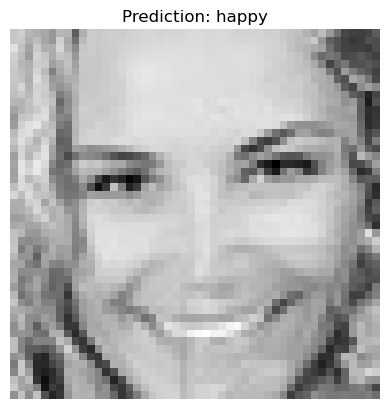

In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.svm import SVC


if 'best_model' not in locals():
    print(" (RBF SVM)...")
    best_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    best_model.fit(X_train_scaled, y_train)

folder_path = r"C:\Users\NO1SC\OneDrive\Desktop\KSIU\Machine Learning\New folder (3)\test\happy"

if os.path.isdir(folder_path):
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if images:
        IMAGE_PATH = os.path.join(folder_path, images[0])
        print(f"Testing images: {images[0]}")
        
        img = Image.open(IMAGE_PATH).convert('L')
        img_resized = img.resize((48, 48))
        img_array = np.array(img_resized, dtype=np.float32) / 255.0
        img_flat = img_array.flatten().reshape(1, -1)

        img_pca = pca.transform(img_flat)
        img_scaled = scaler.transform(img_pca)

        prediction = best_model.predict(img_scaled)[0]
        predicted_emotion = emotion_labels[prediction]

        print(f"\nاthe ruslt: {predicted_emotion}")
        plt.imshow(img_array, cmap='gray')
        plt.title(f"Prediction: {predicted_emotion}")
        plt.axis('off')
        plt.show()
  



<div style="; color: #D4AF37;">
    <h1>Gradio App</h1>
    
</div>

In [48]:
import gradio as gr
import numpy as np
from PIL import Image

def predict_emotion(image):
    
    img = Image.fromarray(image).convert('L')
    img = img.resize((48, 48))
    img_array = np.array(img, dtype=np.float32).flatten() / 255.0
    
    
    img_pca    = pca.transform([img_array])
    img_scaled = scaler.transform(img_pca) 
    

    best_model = results["RBF SVM"]["model"]
    prediction = best_model.predict(img_scaled)[0]
    
    return f"Predicted Emotion: {emotion_labels[prediction]}"


app = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Text(label="Result"),
    title="Facial Expression Recognition",
    description="Upload a face image to predict the emotion"
)
  
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


<div style="text-align: center; color: #D4AF37;">
    <h1>THANK YOU</h1>
    
</div>